<a href="https://colab.research.google.com/github/123nol/ddpm/blob/main/ddpm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

from google.colab import files
files.upload()  # Upload kaggle.json

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

import os, random
from pathlib import Path
import torch
import torchvision
from kaggle import api
import torchvision.transforms as T
import numpy as np
from PIL import Image
from fastdownload import FastDownload
from matplotlib import pyplot as plt
from torch.utils.data import DataLoader



def untar_data(url, force_download=False, base='./datasets'):
    d = FastDownload(base=base)
    return d.get(url, force=force_download, extract_key='data')

def get_data(args):
    train_transforms = torchvision.transforms.Compose([
        T.Resize(args.img_size + int(.25*args.img_size)),  # args.img_size + 1/4 *args.img_size
        T.RandomResizedCrop(args.img_size, scale=(0.8, 1.0)),
        T.ToTensor(),
        T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ])

    val_transforms = torchvision.transforms.Compose([
        T.Resize(args.img_size),
        T.ToTensor(),
        T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ])

    train_dataset = torchvision.datasets.ImageFolder(os.path.join(args.dataset_path, args.train_folder), transform=train_transforms)
    val_dataset = torchvision.datasets.ImageFolder(os.path.join(args.dataset_path, args.val_folder), transform=val_transforms)

    if args.slice_size>1:
        train_dataset = torch.utils.data.Subset(train_dataset, indices=range(0, len(train_dataset), args.slice_size))
        val_dataset = torch.utils.data.Subset(val_dataset, indices=range(0, len(val_dataset), args.slice_size))

    train_dataloader = DataLoader(train_dataset, batch_size=args.batch_size, shuffle=True, num_workers=args.num_workers)
    val_dataset = DataLoader(val_dataset, batch_size=2*args.batch_size, shuffle=False, num_workers=args.num_workers)
    return train_dataloader, val_dataset


def get_alphabet(args):
    get_kaggle_dataset("alphabet", "thomasqazwsxedc/alphabet-characters-fonts-dataset")
    train_transforms = T.Compose([
        T.Grayscale(),
        T.ToTensor(),])
    train_dataset = torchvision.datasets.ImageFolder(root="./alphabet/Images/Images/", transform=train_transforms)
    if args.slice_size>1:
        train_dataset = torch.utils.data.Subset(train_dataset, indices=range(0, len(train_dataset), args.slice_size))
    train_dataloader = DataLoader(train_dataset, batch_size=args.batch_size, shuffle=True, num_workers=args.num_workers)
    return train_dataloader, None

def get_cifar(cifar100=False, img_size=64):

    cifar10_url = 'https://s3.amazonaws.com/fast-ai-sample/cifar10.tgz'
    cifar100_url = 'https://s3.amazonaws.com/fast-ai-imageclas/cifar100.tgz'
    if img_size==32:
        return untar_data(cifar100_url if cifar100 else cifar10_url)
    else:
        get_kaggle_dataset("datasets/cifar10_64", "joaopauloschuler/cifar10-64x64-resized-via-cai-super-resolution")
        return Path("datasets/cifar10_64/cifar10-64")

def get_kaggle_dataset(dataset_path, # Local path to download dataset to
                dataset_slug, # Dataset slug (ie "zillow/zecon")
                unzip=True, # Should it unzip after downloading?
                force=False # Should it overwrite or error if dataset_path exists?
               ):
    '''Downloads an existing dataset and metadata from kaggle'''
    # 'api' is now imported globally in the first cell, no need to import here
    if not force and Path(dataset_path).exists():
        return Path(dataset_path)
    api.dataset_metadata(dataset_slug, str(dataset_path))
    api.dataset_download_files(dataset_slug, str(dataset_path))
    if unzip:
        zipped_file = Path(dataset_path)/f"{dataset_slug.split('/')[-1]}.zip"
        import zipfile
        with zipfile.ZipFile(zipped_file, 'r') as zip_ref:
            zip_ref.extractall(Path(dataset_path))
        zipped_file.unlink()



def plot_images(images):
    plt.figure(figsize=(32, 32))
    plt.imshow(torch.cat([
        torch.cat([i for i in images.cpu()], dim=-1),
    ], dim=-2).permute(1, 2, 0).cpu())
    plt.show()


def mk_folders(run_name):
    os.makedirs("models", exist_ok=True)
    os.makedirs("results", exist_ok=True)
    os.makedirs(os.path.join("models", run_name), exist_ok=True)
    os.makedirs(os.path.join("results", run_name), exist_ok=True)

# path= get_cifar()

Saving kaggle.json to kaggle.json


In [ ]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

# ---------- Utilities

def sinusoidal_time_embedding(t, dim):
    """
    t: (B,) or (B,1) float tensor of timesteps (already scaled to [0, 1] or raw indices you later scale)
    returns: (B, dim)
    """
    if t.dim() == 1:
        t = t[:, None]
    half = dim // 2
    freqs = torch.exp(
        -math.log(10000.0) * torch.arange(half, device=t.device, dtype=t.dtype) / half
    )  # (half,)
    args = t * freqs[None, :]  # (B, half)
    emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)  # (B, 2*half)
    if dim % 2 == 1:
        emb = torch.cat([emb, torch.zeros(emb.size(0), 1, device=t.device, dtype=t.dtype)], dim=-1)
    return emb  # (B, dim)

# ---------- Blocks

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, mid_ch=None, residual=False, groups=32):
        super().__init__()
        self.residual = residual
        mid_ch = out_ch if mid_ch is None else mid_ch
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, mid_ch, kernel_size=3, padding=1, bias=False),
            nn.GroupNorm(min(groups, mid_ch), mid_ch),
            nn.GELU(),
            nn.Conv2d(mid_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.GroupNorm(min(groups, out_ch), out_ch),
            nn.GELU(),
        )
        self.skip = None
        if residual and in_ch != out_ch:
            self.skip = nn.Conv2d(in_ch, out_ch, kernel_size=1)

    def forward(self, x):
        y = self.net(x)
        if self.residual:
            s = x if self.skip is None else self.skip(x)
            y = F.silu(y + s)
        return y

class AddTime(nn.Module):
    """Inject a time (and optional class) embedding as a channel-wise bias."""
    def __init__(self, time_dim, out_ch):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(time_dim, out_ch),
            nn.SiLU(),
            nn.Linear(out_ch, out_ch),
        )

    def forward(self, x, temb):
        # x: (B, C, H, W), temb: (B, time_dim)
        b, c, h, w = x.shape
        e = self.proj(temb).view(b, c, 1, 1)
        return x + e

class SelfAttention2D(nn.Module):
    """MHSA over (H*W) tokens, returns (B, C, H, W)."""
    def __init__(self, channels, num_heads=4, residual=False):
        super().__init__()
        self.residual = residual
        self.norm = nn.LayerNorm(channels)
        self.attn = nn.MultiheadAttention(
            embed_dim=channels, num_heads=num_heads, batch_first=True
        )
        self.mlp = nn.Sequential(
            nn.Linear(channels, channels),
            nn.SiLU(),
            nn.Linear(channels, channels),
        )

    def forward(self, x):
        b, c, h, w = x.shape
        seq = x.view(b, c, h * w).permute(0, 2, 1)  # (B, N, C)
        res = seq
        y = self.norm(seq)
        y, _ = self.attn(y, y, y)      # (B, N, C)
        y = self.mlp(y)                 # (B, N, C)
        if self.residual:
            y = F.gelu(y + res)
        y = y.permute(0, 2, 1).view(b, c, h, w)
        return y

class Down(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()
        self.block1 = ConvBlock(in_ch, out_ch, residual=True)
        self.block2 = ConvBlock(out_ch, out_ch, residual=False)
        self.add_time = AddTime(time_dim, out_ch)
        self.pool = nn.MaxPool2d(2)

    def forward(self, x, temb):
        x = self.block1(x)
        x = self.block2(x)
        x = self.add_time(x, temb)
        x_down = self.pool(x)
        return x, x_down  # return skip and downsampled

class Up(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch, time_dim):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode="nearest")
        self.block1 = ConvBlock(in_ch + skip_ch, out_ch, residual=True)
        self.block2 = ConvBlock(out_ch, out_ch, residual=False)
        self.add_time = AddTime(time_dim, out_ch)

    def forward(self, x, skip, temb):
        x = self.up(x)
        x = torch.cat([x, skip], dim=1)
        x = self.block1(x)
        x = self.block2(x)
        x = self.add_time(x, temb)
        return x

# ---------- UNet

class UNetDDPM(nn.Module):
    def __init__(self, in_channels=1, base=32, time_dim=256, num_classes=None, attn_levels=(1,2)):
        """
        attn_levels: which down/up index levels include attention (0=highest resolution)
        """
        super().__init__()
        self.time_dim = time_dim
        self.num_classes = num_classes
        self.label_emb = nn.Embedding(num_classes, time_dim) if num_classes is not None else None

        # Stem
        self.stem = ConvBlock(in_channels, base, residual=False)

        # Down path
        self.down1 = Down(base,   base*2, time_dim)  # level 0
        self.att1d = SelfAttention2D(base*2, residual=True) if 0 in attn_levels else nn.Identity()
        self.down2 = Down(base*2, base*4, time_dim)  # level 1
        self.att2d = SelfAttention2D(base*4, residual=True) if 1 in attn_levels else nn.Identity()
        self.down3 = Down(base*4, base*4, time_dim)  # level 2
        self.att3d = SelfAttention2D(base*4, residual=True) if 2 in attn_levels else nn.Identity()

        # Bottleneck
        self.bot1 = ConvBlock(base*4, base*8, residual=True)
        self.bot2 = ConvBlock(base*8, base*8, residual=True)

        # Up path (mirror; pay attention to skip channels)
        self.up1  = Up(in_ch=base*8, skip_ch=base*4, out_ch=base*4, time_dim=time_dim)  # with skip from down3
        self.att1u = SelfAttention2D(base*4, residual=True) if 2 in attn_levels else nn.Identity()
        self.up2  = Up(in_ch=base*4, skip_ch=base*4, out_ch=base*2, time_dim=time_dim)  # with skip from down2, CORRECTED skip_ch
        self.att2u = SelfAttention2D(base*2, residual=True) if 1 in attn_levels else nn.Identity()
        self.up3  = Up(in_ch=base*2, skip_ch=base*2, out_ch=base,   time_dim=time_dim)  # with skip from down1, CORRECTED skip_ch
        self.att3u = SelfAttention2D(base, residual=True) if 0 in attn_levels else nn.Identity()

        # Head
        self.head = nn.Conv2d(base, in_channels, kernel_size=1)

    def time_label_embed(self, t, label=None):
        temb = sinusoidal_time_embedding(t, self.time_dim)
        if self.label_emb is not None and label is not None:
            temb = temb + self.label_emb(label)
        return temb

    def forward(self, x, t, label=None):
        """
        x: (B, 3, H, W)
        t: (B,) float or long timesteps
        label: (B,) optional class labels for conditional DDPM
        """
        if t.dtype in (torch.long, torch.int32, torch.int64):
            t = t.float()
        temb = self.time_label_embed(t, label)  # (B, time_dim)

        x0 = self.stem(x)

        s1, x1 = self.down1(x0, temb) ; x1 = self.att1d(x1)
        s2, x2 = self.down2(x1, temb) ; x2 = self.att2d(x2)
        s3, x3 = self.down3(x2, temb) ; x3 = self.att3d(x3)

        b  = self.bot1(x3)
        b  = self.bot2(b)

        u1 = self.up1(b,  s3, temb) ; u1 = self.att1u(u1)
        u2 = self.up2(u1, s2, temb) ; u2 = self.att2u(u2)
        u3 = self.up3(u2, s1, temb) ; u3 = self.att3u(u3)

        out = self.head(u3)
        return out

In [ ]:
import torch
import math

import argparse, logging, copy
from types import SimpleNamespace
from contextlib import nullcontext


from torch import optim
import torch.nn as nn
import numpy as np
from fastprogress import progress_bar

# from utils.py import *



class Diffusion:
    def __init__(self, num_classes, in_channels=1, timesteps=1000, img_size=256, ddim_timesteps=50, device="cuda"):
        self.beta, self.abar = self.cosine_beta_schedule_torch(timesteps, device=device)
        self.model = UNetDDPM(in_channels=in_channels, num_classes=num_classes)
        self.timesteps = timesteps
        self.img_size = img_size
        self.in_channels = in_channels
        self.ddim_timesteps = ddim_timesteps
        self.device = device


    @staticmethod
    def cosine_beta_schedule_torch(T, s=0.008, max_beta=0.999, device=None, dtype=torch.float32):
        t = torch.linspace(0, T, T + 1, device=device, dtype=torch.float64)
        f = torch.cos(((t / T + s) / (1.0 + s)) * math.pi / 2.0) ** 2
        abar = f / f[0]
        alphas = (abar[1:] / abar[:-1]).to(dtype)
        betas = (1.0 - alphas).clamp_(min=0.0, max=max_beta)
        return betas, abar.to(dtype)

    def sample_timesteps(self, n):
        return torch.randint(low=0, high=self.timesteps, size=(n,), device=self.device)

    def noise_image(self, x_0, t):
        sqrt_abar = torch.sqrt(self.abar[t])[:, None, None, None]
        sqrt_one_minus_abar = torch.sqrt(1 - self.abar[t])[:, None, None, None]
        eps = torch.randn_like(x_0)
        return sqrt_abar * x_0 + sqrt_one_minus_abar * eps, eps


    def one_epoch(self, train=True):
        avg_loss = 0.
        if train: self.model.train()
        else: self.model.eval()
        pbar = progress_bar(self.train_dataloader, leave=False)
        for i, (images, labels) in enumerate(pbar):
            with torch.autocast("cuda") and (torch.inference_mode() if not train else torch.enable_grad()):
                images = images.to(self.device)
                labels = labels.to(self.device)
                t = self.sample_timesteps(images.shape[0]).to(self.device)
                x_t, noise = self.noise_image(images, t)
                if np.random.random() < 0.1:
                    labels = None
                predicted_noise = self.model(x_t, t, labels)
                loss = self.mse(noise, predicted_noise)
                avg_loss += loss
            if train:
                self.train_step(loss)

            pbar.comment = f"MSE={loss.item():2.3f}"
        return avg_loss.mean().item()



    @torch.no_grad()
    def ddim_indices_torch(self, T, N, method="time", device=None, dtype=torch.float64):
        # Ensure we use the correct device
        if device is None:
            device = self.device

        if method == "time":
            tau = torch.round(torch.linspace(0, T, N + 1, device=device)).to(torch.long)
            return torch.unique(tau)

        # --- log-SNR method ---
        eps = torch.finfo(dtype).eps
        # Use self.abar which is already on the correct device
        logsnr = torch.log(self.abar / (1.0 - self.abar + eps))

        logsnr_rev = torch.flip(logsnr, dims=[0])
        # Crucial fix: ensure grid is on the same device as logsnr_rev
        grid = torch.linspace(logsnr[0].item(), logsnr[-1].item(), N + 1, device=device, dtype=dtype)
        grid_rev = torch.flip(grid, dims=[0])

        idx_rev = torch.searchsorted(logsnr_rev, grid_rev, right=False)
        tau = (T - idx_rev).clamp(min=0, max=T).to(torch.long)
        tau, _ = torch.sort(tau)
        return torch.unique(tau)

    @torch.no_grad()
    def ddim_sample_with_intermediates(self, label, guide_scale=3., capture_interval=10, N=50):
        self.model.eval()
        batch_size = label.shape[0]

        # 1. Correct Shape: (Batch, Channels, Height, Width)
        x = torch.randn((batch_size, self.in_channels, self.img_size, self.img_size), device=self.device)

        # 2. Get DDIM schedule
        tau = self.ddim_indices_torch(self.timesteps, N, method="time")
        # Reverse tau for sampling: [T, ..., 0]
        tau = torch.flip(tau, dims=[0])

        intermediates = []

        for i in range(len(tau) - 1):
            t_now = tau[i]
            t_next = tau[i+1]

            # Create tensors for model input
            t_tensor = torch.full((batch_size,), t_now, device=self.device, dtype=torch.long)

            # 3. Model Prediction (Guidance)
            pre_pred_noise = self.model(x, t_tensor, label)
            uncond_pred = self.model(x, t_tensor, None)
            pred_noise = torch.lerp(uncond_pred, pre_pred_noise, guide_scale)

            # 4. DDIM Logic
            abar_now = self.abar[t_now].view(-1, 1, 1, 1)
            abar_next = self.abar[t_next].view(-1, 1, 1, 1)

            # Predict x0
            x0_hat = (x - torch.sqrt(1 - abar_now) * pred_noise) / torch.sqrt(abar_now)

            # Compute x_next
            x = torch.sqrt(abar_next) * x0_hat + torch.sqrt(1 - abar_next) * pred_noise

            # 5. Capture snapshot
            if i % capture_interval == 0 or i == len(tau) - 2:
                # Normalize and move to CPU for plotting
                out = (x.clamp(-1, 1) + 1) / 2
                out = (out * 255).type(torch.uint8)
                intermediates.append(out.cpu())

        return intermediates





    @torch.inference_mode()
    def ddpm_sample_with_intermediates(self, label, guide_scale=3., capture_interval=100):
        self.model.eval()
        # Shape must be (Batch, Channels, Height, Width)
        x = torch.randn((label.shape[0], self.in_channels, self.img_size, self.img_size), device=self.device)
        intermediates = []

        for i in reversed(range(0, self.timesteps)):
            # Create a batch of timesteps as Tensors
            t_tensor = torch.full((label.shape[0],), i, device=self.device, dtype=torch.long)

            # Classifier-Free Guidance
            pre_pred_noise = self.model(x, t_tensor, label)
            uncond_pred = self.model(x, t_tensor, None)
            pred_noise = torch.lerp(uncond_pred, pre_pred_noise, guide_scale)

            # Get constants for current t and reshape for broadcasting
            beta = self.beta[i].view(-1, 1, 1, 1)
            abar = self.abar[i].view(-1, 1, 1, 1)
            abar_next = self.abar[i+1].view(-1, 1, 1, 1)

            noise = torch.randn_like(x) if i > 0 else 0

            # DDPM Step
            # Formula: x_{t-1} = 1/sqrt(alpha) * (x_t - (1-alpha)/sqrt(1-abar) * eps) + sigma*z
            alpha = 1 - beta
            x = (1 / torch.sqrt(alpha)) * (x - ((1 - alpha) / torch.sqrt(1 - abar_next)) * pred_noise) + torch.sqrt(beta) * noise

            if i % capture_interval == 0 or i == 0:
                # Normalize to 0-255 for visualization
                out = (x.clamp(-1, 1) + 1) / 2
                out = (out * 255).type(torch.uint8)
                intermediates.append(out.cpu())

        return intermediates

    def train_step(self, loss):
          self.optimizer.zero_grad()
          self.scaler.scale(loss).backward()
          self.scaler.step(self.optimizer)
          self.scaler.update()

          self.scheduler.step()




    def one_epoch(self, train=True):
          avg_loss = 0.
          if train: self.model.train()
          else: self.model.eval()
          pbar = progress_bar(self.train_dataloader, leave=False)
          for i, (images, labels) in enumerate(pbar):
              with torch.autocast("cuda") and (torch.inference_mode() if not train else torch.enable_grad()):
                  images = images.to(self.device)
                  labels = labels.to(self.device)
                  t = self.sample_timesteps(images.shape[0]).to(self.device)
                  x_t, noise = self.noise_image(images, t)
                  if np.random.random() < 0.1:
                      labels = None
                  predicted_noise = self.model(x_t, t, labels)
                  loss = self.mse(noise, predicted_noise)
                  avg_loss += loss
              if train:
                  self.train_step(loss)

              pbar.comment = f"MSE={loss.item():2.3f}"
          return avg_loss.mean().item()


    def load(self, path):
        # If the path passed is a directory, look for ckpt.pt inside it
        if os.path.isdir(path):
            path = os.path.join(path, "ckpt.pt")

        # Load the state dict and map it to the correct device (cpu/cuda)
        state_dict = torch.load(path, map_location=self.device)

        # Load into the model
        self.model.load_state_dict(state_dict)
        self.model.to(self.device)
        self.model.eval()
        print(f"Model loaded successfully from {path}")


    def save_model(self, run_name, epoch=-1):

          torch.save(self.model.state_dict(), os.path.join("models", run_name, f"ckpt.pt"))

          torch.save(self.optimizer.state_dict(), os.path.join("models", run_name, f"optim.pt"))


    def prepare(self, args):
          mk_folders(args.run_name)
          self.train_dataloader, self.val_dataloader = get_alphabet(args)
          self.model.to(self.device) # Add this line to move the model to the correct device
          self.optimizer = optim.AdamW(self.model.parameters(), lr=args.lr, eps=1e-5)
          self.scheduler = optim.lr_scheduler.OneCycleLR(self.optimizer, max_lr=args.lr,
                                                  steps_per_epoch=len(self.train_dataloader), epochs=args.epochs)
          self.mse = nn.MSELoss()

          self.scaler = torch.cuda.amp.GradScaler()

    def fit(self, args):
          for epoch in progress_bar(range(args.epochs), total=args.epochs, leave=True):
              logging.info(f"Starting epoch {epoch}:")
              _  = self.one_epoch(train=True)

              ## validation
              if args.do_validation:
                  avg_loss = self.one_epoch(train=False)

          # save model
          self.save_model(run_name=args.run_name, epoch=epoch)

In [ ]:
from types import SimpleNamespace
config = SimpleNamespace(
    run_name        = "DDPM_alphabet",
    epochs          = 20,
    noise_steps     = 1000,
    seed            = 42,
    batch_size      = 64,
    img_size        = 32,
    num_classes     = 26,
    c_in            = 1,       # grayscale
    c_out           = 1,       # grayscale
    slice_size      = 1,
    do_validation   = False,
    log_every_epoch = 2,
    fp16            = True,
    num_workers     = 2,
    device          = "cuda",
    lr              = 5e-3,
)



diff = Diffusion(
    timesteps   = config.noise_steps,
    img_size    = config.img_size,
    num_classes = config.num_classes,
    in_channels = config.c_in,
    device      = config.device
)
diff.prepare(config)
diff.fit(config)


/tmp/ipython-input-1811/4150756795.py:228: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler()


<div><progress max="20" value="20"></progress> 100.00% [20/20 3:08:56&lt;00:00]</div>

In [ ]:
diff2=Diffusion(
    timesteps   = config.noise_steps,
    img_size    = config.img_size,
    num_classes = config.num_classes,
    in_channels = config.c_in,
    device      = config.device

)

diff2.load("/content/models/DDPM_alphabet/ckpt.pt")

Model loaded successfully from /content/models/DDPM_alphabet/ckpt.pt


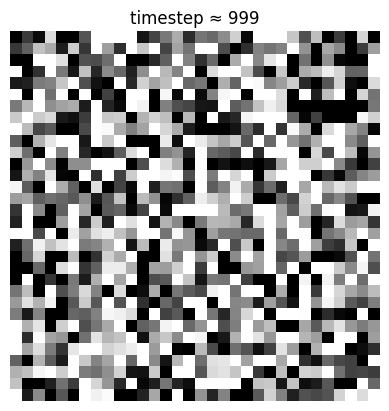

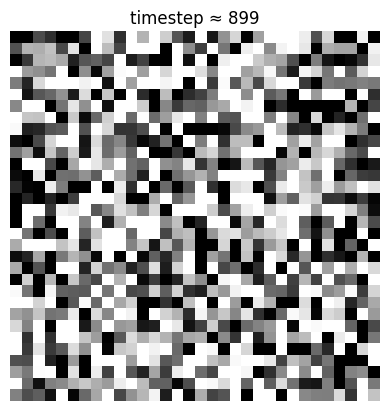

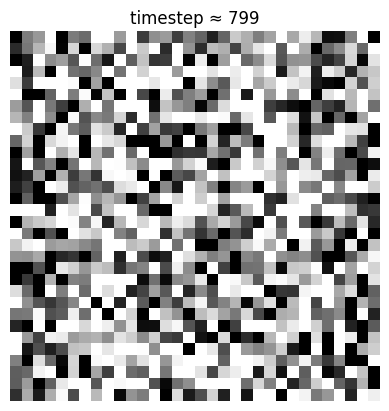

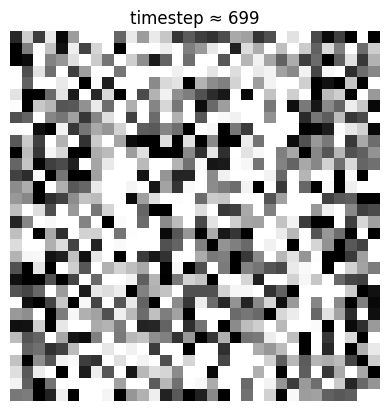

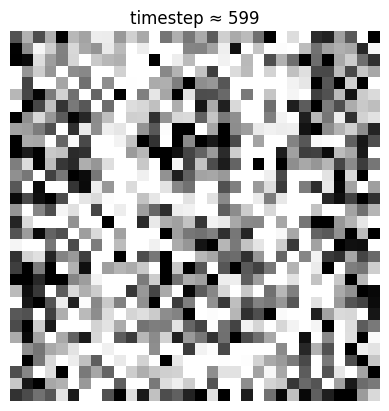

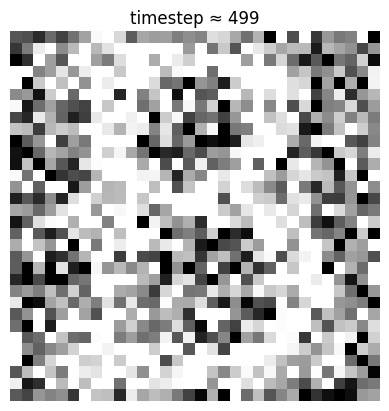

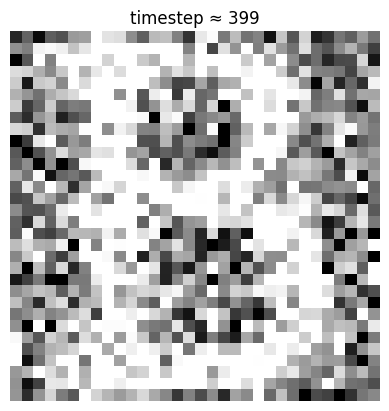

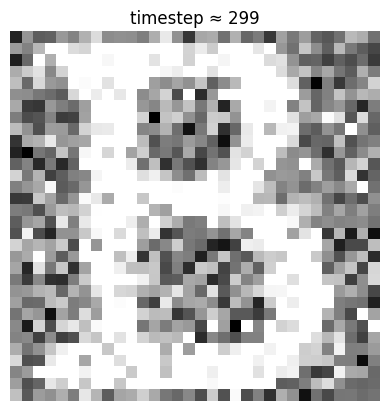

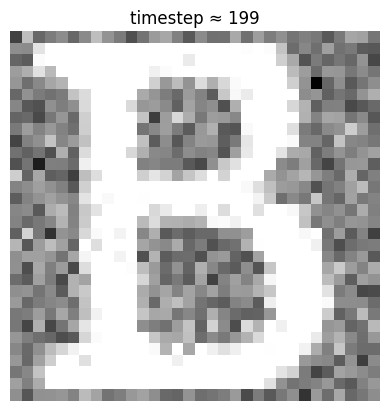

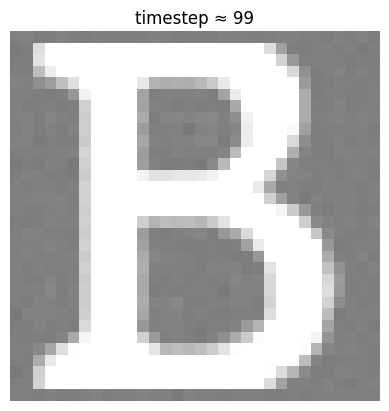

In [ ]:
import torch
import matplotlib.pyplot as plt

# 1) Map class indices to letters
alphabet_labels = "A B C D E F G H I J K L M N O P Q R S T U V W X Y Z".split(" ")
prompt = "B"
label_id = alphabet_labels.index(prompt)   # → 0

# 2) Build a batch of size 1 with that label
labels = torch.tensor([label_id], dtype=torch.long).to(diff2.device)

# 3) Run the sampling with intermediates every 100 steps
intermediates = diff2.ddpm_sample_with_intermediates(
             # use the EMA weights for sharper results
    label=labels,
    guide_scale=3.0,          # classifier-free guidance strength
    capture_interval=100    # snapshot every 100 steps
)

# 4) Plot each snapshot
for idx, batch in enumerate(intermediates):
    img = batch[0]  # shape [C, H, W]
    # grayscale if C==1, else RGB
    if img.shape[0] == 1:
        plt.imshow(img.squeeze(0).cpu().numpy(), cmap="gray", vmin=0, vmax=255)
    else:
        plt.imshow(img.permute(1, 2, 0).cpu().numpy())
    step = (diff2.timesteps - 1) - idx * 100
    plt.title(f"timestep ≈ {step}")
    plt.axis("off")
    plt.show()

In [ ]:
diff3=Diffusion(
    timesteps   = 1000,
    img_size    = config.img_size,
    num_classes = config.num_classes,
    in_channels = config.c_in,
    device      = config.device

)

diff3.load("/content/models/DDPM_alphabet/ckpt.pt")

Model loaded successfully from /content/models/DDPM_alphabet/ckpt.pt


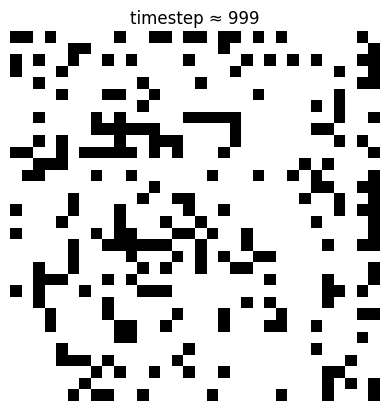

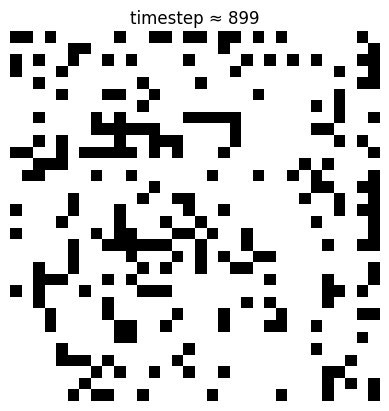

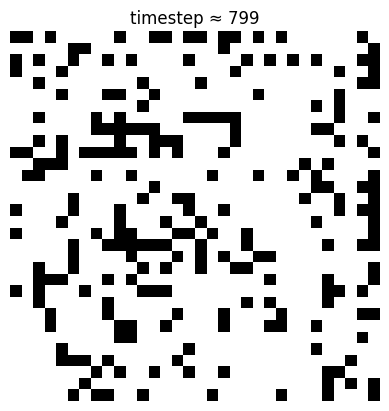

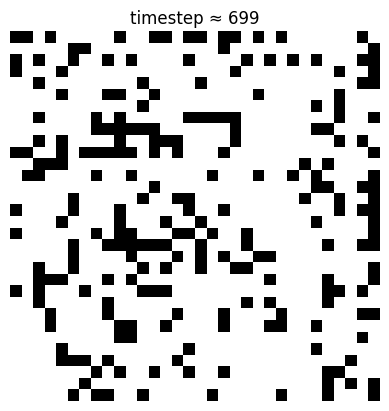

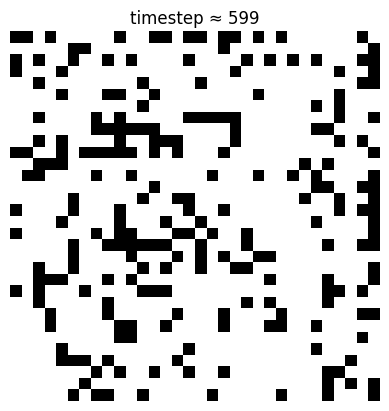

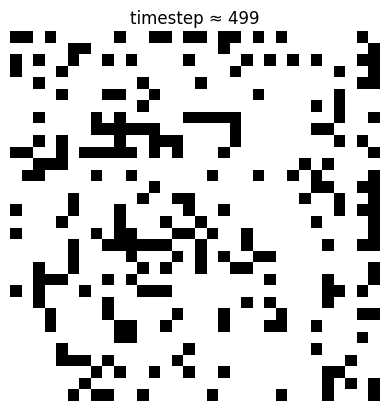

In [ ]:
import torch
import matplotlib.pyplot as plt

# 1) Map class indices to letters
alphabet_labels = "A B C D E F G H I J K L M N O P Q R S T U V W X Y Z".split(" ")
prompt = "B"
label_id = alphabet_labels.index(prompt)   # → 0

# 2) Build a batch of size 1 with that label
labels = torch.tensor([label_id], dtype=torch.long).to(diff3.device)

# 3) Run the sampling with intermediates every 100 steps
intermediates = diff3.ddim_sample_with_intermediates(
             # use the EMA weights for sharper results
    label=labels,
    guide_scale=3.0,          # classifier-free guidance strength
    capture_interval=10    # snapshot every 100 steps
)

# 4) Plot each snapshot
for idx, batch in enumerate(intermediates):
    img = batch[0]  # shape [C, H, W]
    # grayscale if C==1, else RGB
    if img.shape[0] == 1:
        plt.imshow(img.squeeze(0).cpu().numpy(), cmap="gray", vmin=0, vmax=255)
    else:
        plt.imshow(img.permute(1, 2, 0).cpu().numpy())
    step = (diff3.timesteps - 1) - idx * 100
    plt.title(f"timestep ≈ {step}")
    plt.axis("off")
    plt.show()

In [ ]:
import torch
import matplotlib.pyplot as plt

# 1) Map class indices to letters
cifar_labels = "airplane,automobile,bird,cat,deer,dog,frog,horse,ship,truck".split(",")
prompt = "cat"
label_id = cifar_labels.index(prompt)   # → 0

# 2) Build a batch of size 1 with that label
labels = torch.tensor([label_id], dtype=torch.long).to(diff.device)

# 3) Run the sampling with intermediates every 100 steps
intermediates = diff.ddpm_sample_with_intermediates(
    use_ema=False,           # use the EMA weights for sharper results
    labels=label_id,
    guide_scale=3.0,          # classifier-free guidance strength
    capture_interval=100    # snapshot every 100 steps
)

# 4) Plot each snapshot
for idx, batch in enumerate(intermediates):
    img = batch[0]  # shape [C, H, W]
    # grayscale if C==1, else RGB
    if img.shape[0] == 1:
        plt.imshow(img.squeeze(0).cpu().numpy(), cmap="gray", vmin=0, vmax=255)
    else:
        plt.imshow(img.permute(1, 2, 0).cpu().numpy())
    step = (diff2.timesteps - 1) - idx * 100
    plt.title(f"timestep ≈ {step}")
    plt.axis("off")
    plt.show()

In [ ]:
import torch
import matplotlib.pyplot as plt

# 1) Map class indices to letters
cifar_labels = "airplane,automobile,bird,cat,deer,dog,frog,horse,ship,truck".split(",")
prompt = "cat"
label_id = cifar_labels.index(prompt)   # → 0

# 2) Build a batch of size 1 with that label
labels = torch.tensor([label_id], dtype=torch.long).to(diff.device)

# 3) Run the sampling with intermediates every 100 steps
intermediates = diff.ddim_sample_with_intermediates(
    use_ema=False,           # use the EMA weights for sharper results
    labels=labels,
    guide_scale=3.0,          # classifier-free guidance strength
    capture_interval=100    # snapshot every 100 steps
)

# 4) Plot each snapshot
for idx, batch in enumerate(intermediates):
    img = batch[0]  # shape [C, H, W]
    # grayscale if C==1, else RGB
    if img.shape[0] == 1:
        plt.imshow(img.squeeze(0).cpu().numpy(), cmap="gray", vmin=0, vmax=255)
    else:
        plt.imshow(img.permute(1, 2, 0).cpu().numpy())
    step = (diff.noise_steps - 1) - idx * 100
    plt.title(f"timestep ≈ {step}")
    plt.axis("off")
    plt.show()